# Classic Path Planning Algorithms

This notebook demonstrates the various path planning algorithms available in the `pathplan` library.

In [2]:
import numpy as np
from pathplan.core import GridMap
from pathplan.classic import (
    AStarPlanner, 
    RRTPlanner, 
    RRTStarPlanner, 
    ThetaStarPlanner,
    DijkstraPlanner,
    BidirectionalAStarPlanner,
    JPSPlanner,
    DStarLitePlanner,
    PRMPlanner,
    InformedRRTStarPlanner,
    APFPlanner,
    Bug2Planner
)
from pathplan.utils import Visualizer

In [3]:
# Recreating the scenario map parameters
maze_data = np.zeros((20, 20))

# Vertical wall with an open gap
maze_data[5:15, 10] = 1.0
maze_data[10, 10] = 0.0  

# Horizontal wall with an open gap
maze_data[12, 3:17] = 1.0
maze_data[12, 8] = 0.0   

# Static block obstacles
maze_data[3:5, 3:5] = 1.0
maze_data[7:9, 15:18] = 1.0
maze_data[16:18, 5:7] = 1.0

# Define start and goal configurations (row, col indices)
start_node = (0, 0)
goal_node = (19, 19)

# Instantiate the normalized GridMap wrapper
grid_map = GridMap(maze_data)
print(f"GridMap successfully initialized with shape: {grid_map.shape}")

GridMap successfully initialized with shape: (20, 20)



Running A* planner...
SUCCESS: Valid trajectory discovered for A*!


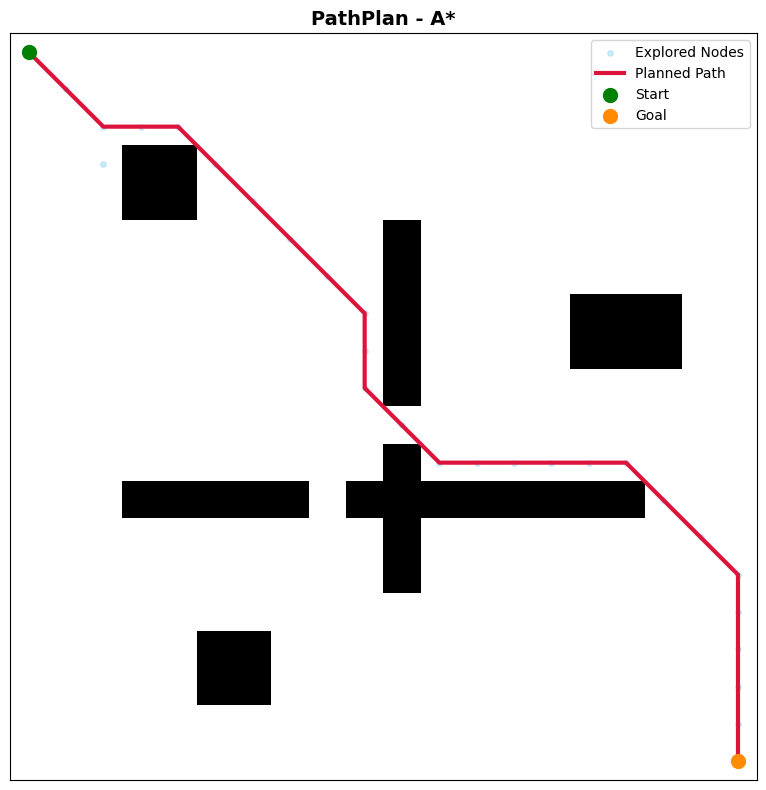


Running Dijkstra planner...
SUCCESS: Valid trajectory discovered for Dijkstra!


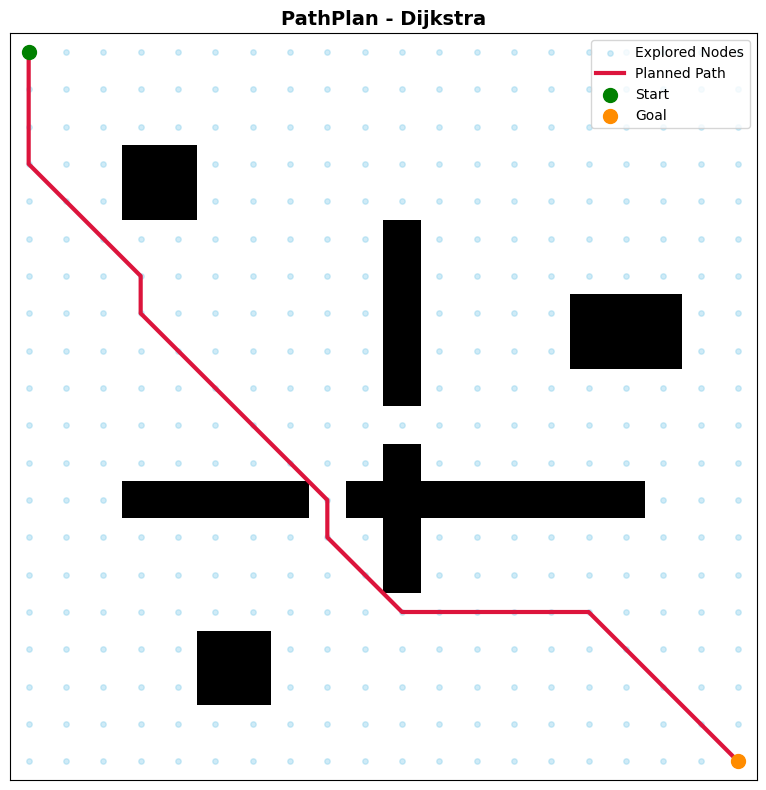


Running Bidirectional A* planner...
SUCCESS: Valid trajectory discovered for Bidirectional A*!


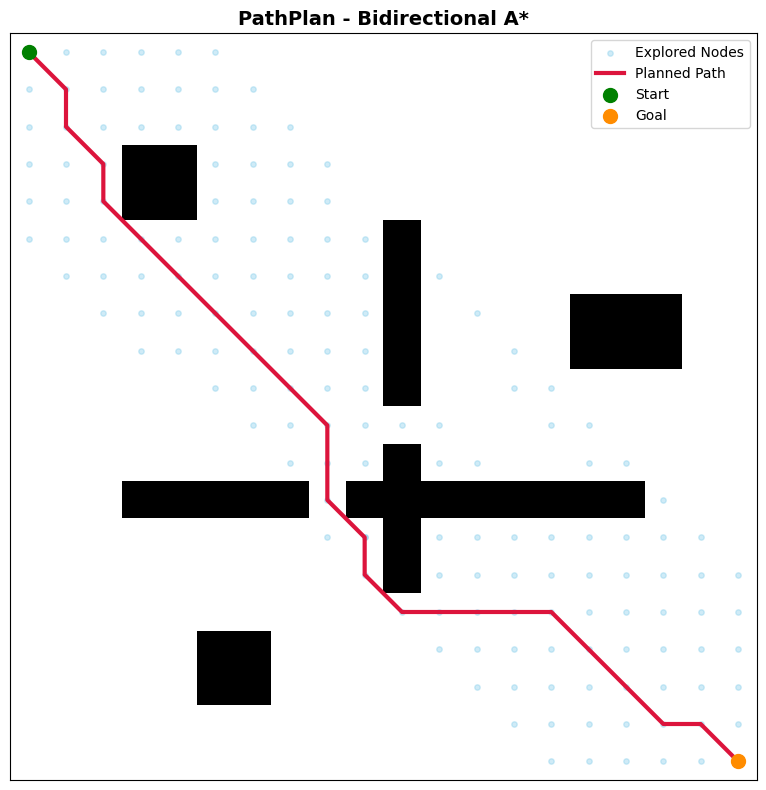


Running Jump Point Search (JPS) planner...
SUCCESS: Valid trajectory discovered for Jump Point Search (JPS)!


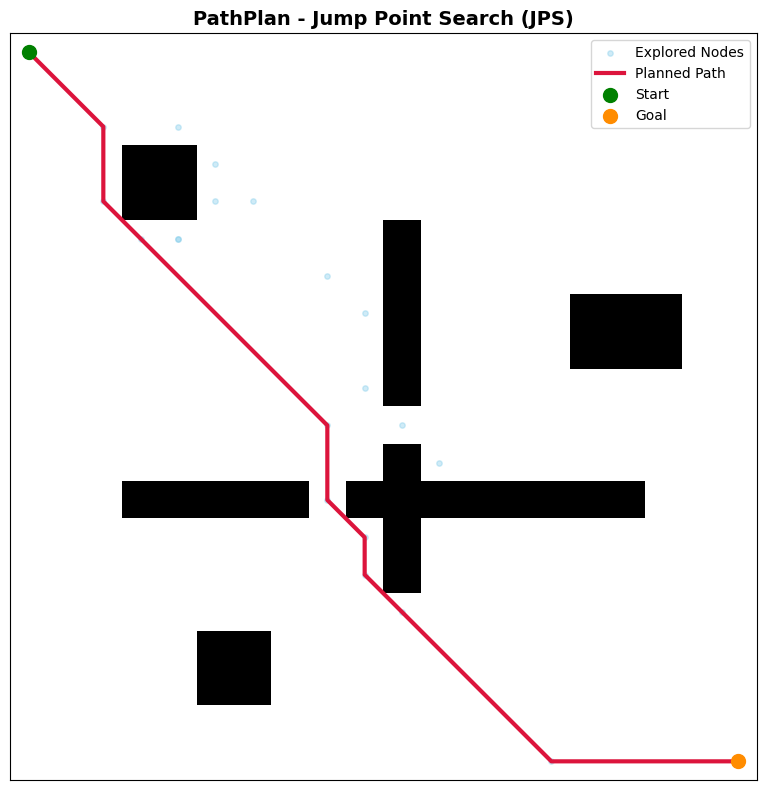


Running Theta* planner...
SUCCESS: Valid trajectory discovered for Theta*!


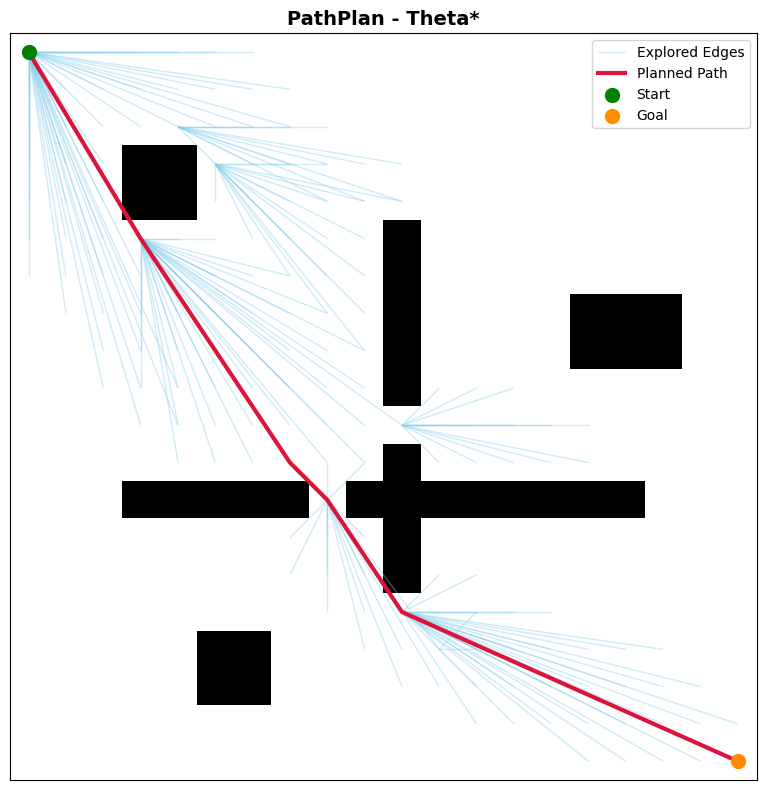


Running D* Lite planner...
SUCCESS: Valid trajectory discovered for D* Lite!


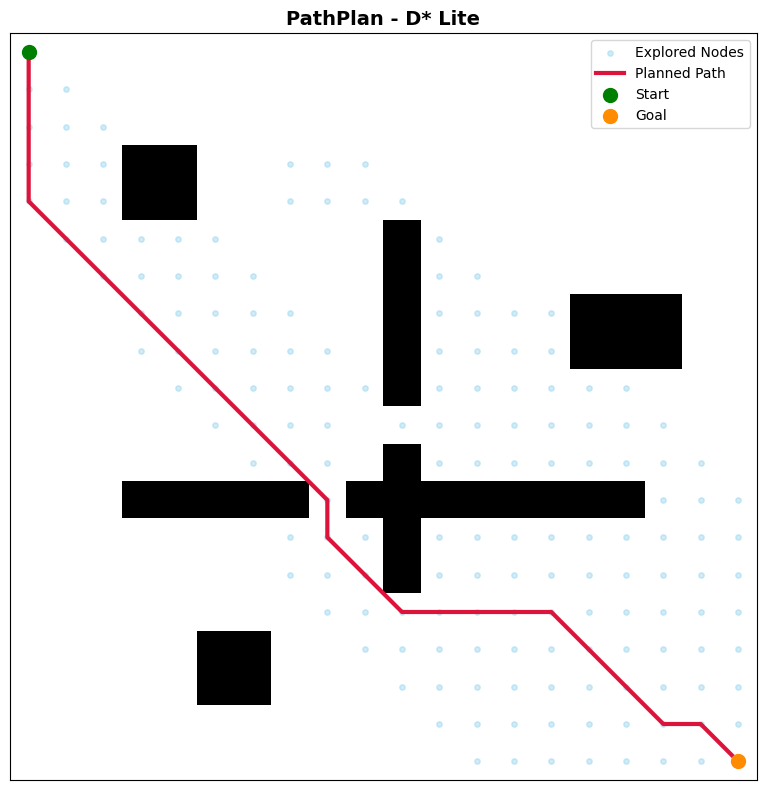


Running RRT planner...
SUCCESS: Valid trajectory discovered for RRT!


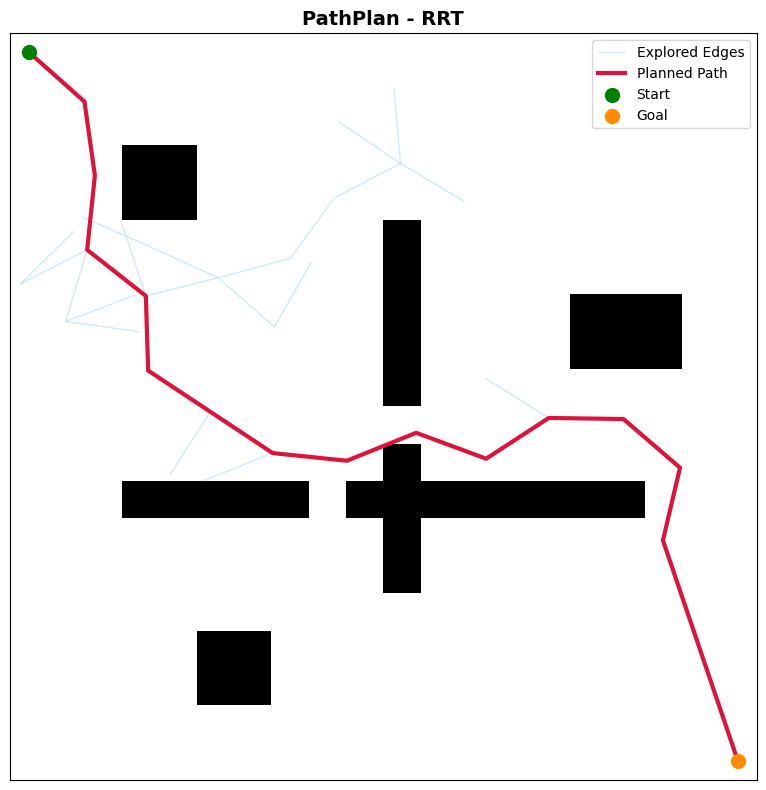


Running RRT* planner...
SUCCESS: Valid trajectory discovered for RRT*!


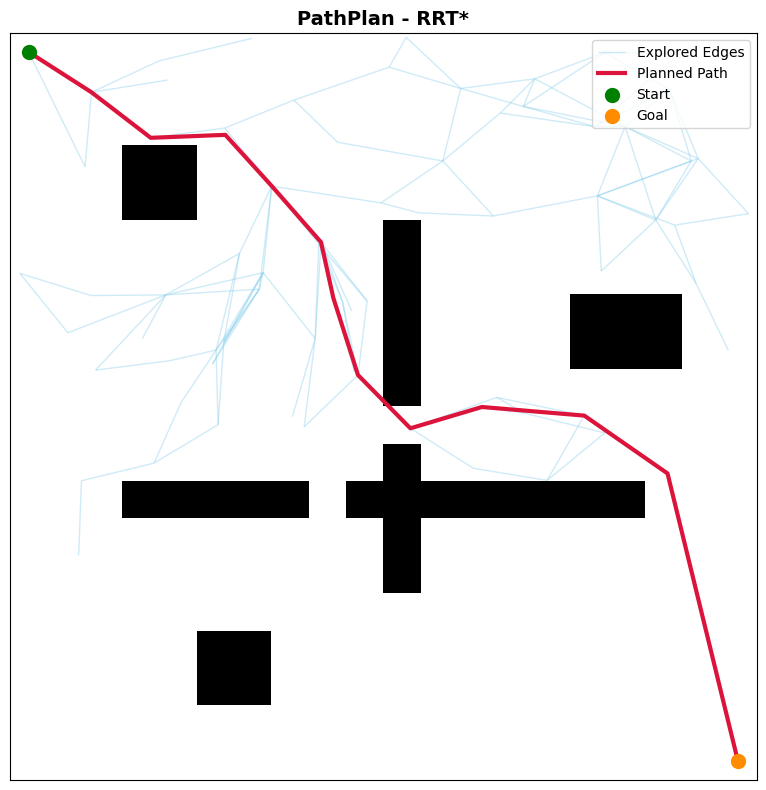


Running Informed RRT* planner...
SUCCESS: Valid trajectory discovered for Informed RRT*!


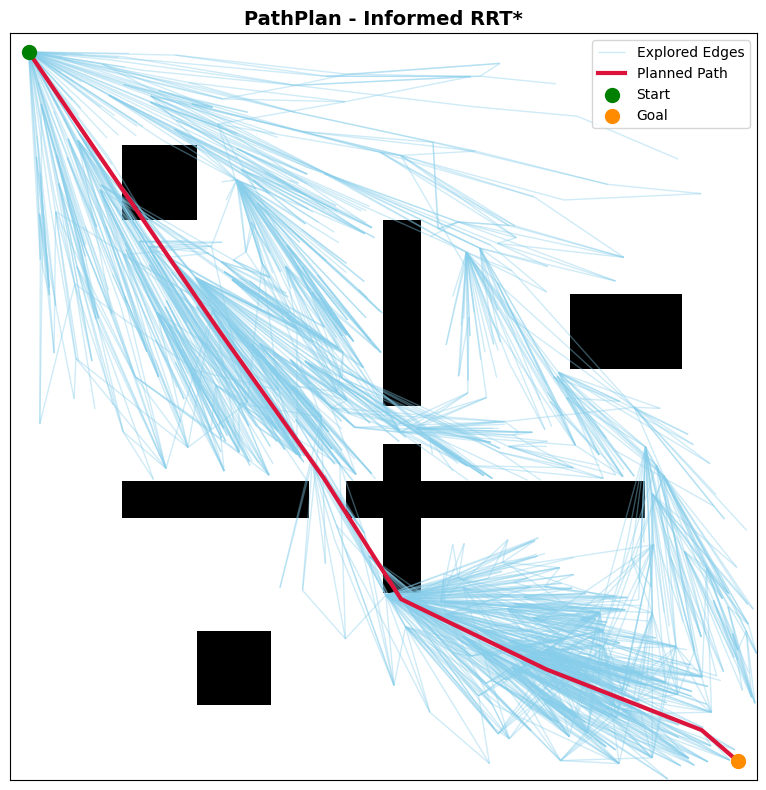


Running PRM planner...
SUCCESS: Valid trajectory discovered for PRM!


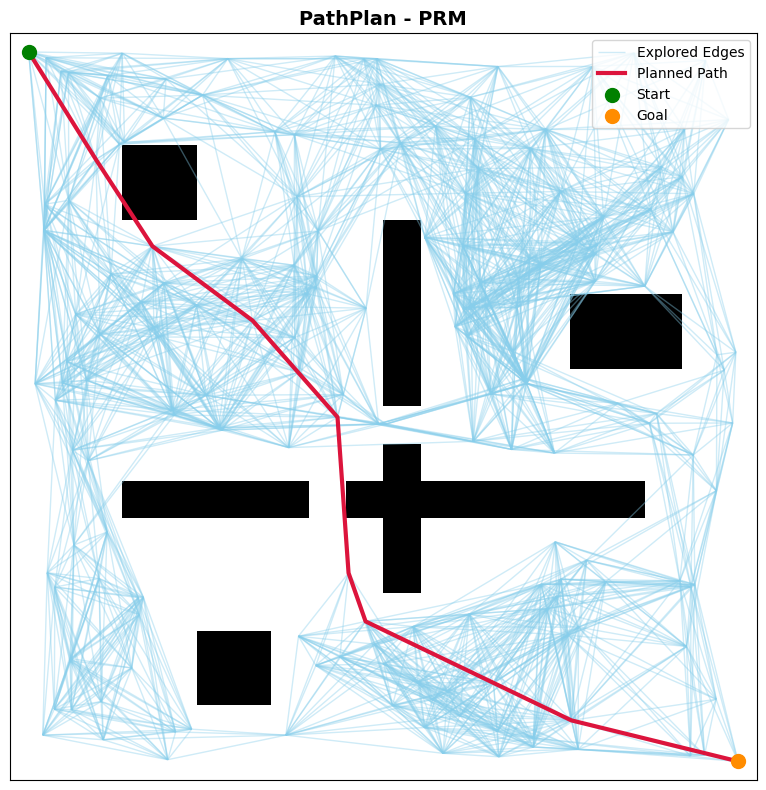


Running APF planner...
FAILURE: APF could not find a valid path.

Running Bug2 planner...
SUCCESS: Valid trajectory discovered for Bug2!


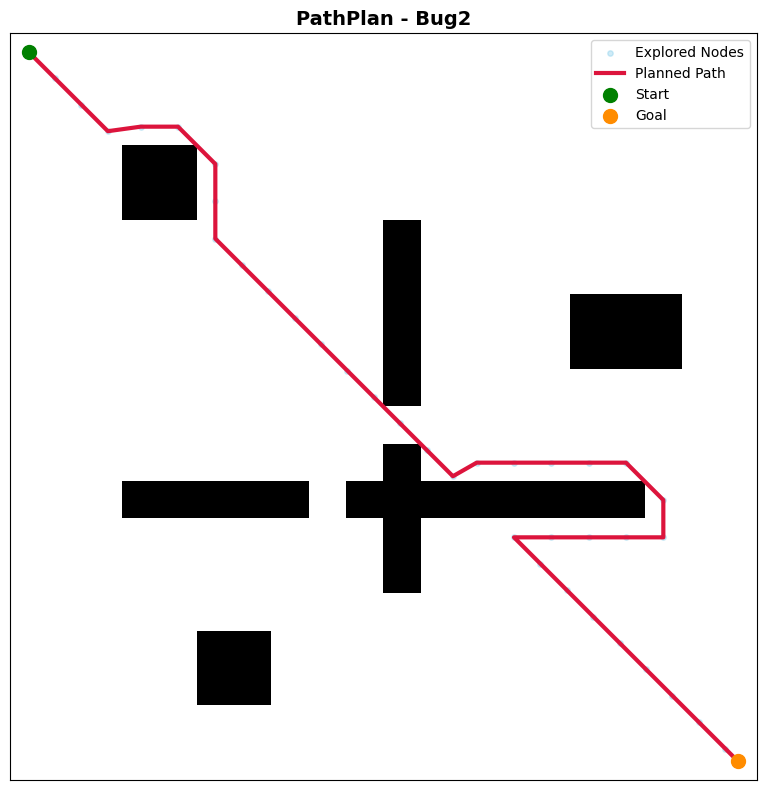

In [4]:
# Define the planners to demonstrate
planners = [
    ("A*", AStarPlanner(grid_map)),
    ("Dijkstra", DijkstraPlanner(grid_map)),
    ("Bidirectional A*", BidirectionalAStarPlanner(grid_map)),
    ("Jump Point Search (JPS)", JPSPlanner(grid_map)),
    ("Theta*", ThetaStarPlanner(grid_map)),
    ("D* Lite", DStarLitePlanner(grid_map)),
    ("RRT", RRTPlanner(grid_map)),
    ("RRT*", RRTStarPlanner(grid_map)),
    ("Informed RRT*", InformedRRTStarPlanner(grid_map)),
    ("PRM", PRMPlanner(grid_map)),
    ("APF", APFPlanner(grid_map)),
    ("Bug2", Bug2Planner(grid_map)),
]

viz = Visualizer(grid_map)

for name, planner in planners:
    print(f"\nRunning {name} planner...")
    path, explored = planner.plan(start_node, goal_node)
    
    if path:
        print(f"SUCCESS: Valid trajectory discovered for {name}!")
        # For sampling-based planners, 'explored' might be edges, 
        # Visualizer.plot_path handles both points and edges.
        viz.plot_path(
            path=path, 
            explored=explored, 
            title=f"PathPlan - {name}"
        )
    else:
        print(f"FAILURE: {name} could not find a valid path.")